# Fraud Detection Using Supervised Machine Learning

## Importing Required Libraries:

In [20]:
!python -m pip install --upgrade pip

In [22]:
import importlib, sys

def show_pkg(name):
    try:
        m = importlib.import_module(name)
        print(f"{name} version:", getattr(m, "__version__", "unknown"))
        print(f"{name} path: {m.__file__}\n")
    except Exception as e:
        print(f"{name} import failed: {e}\n")

show_pkg('sklearn')
show_pkg('imblearn')


sklearn version: 1.7.2
sklearn path: C:\Users\ACER\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\__init__.py

imblearn version: 0.14.0
imblearn path: C:\Users\ACER\AppData\Local\Programs\Python\Python313\Lib\site-packages\imblearn\__init__.py



In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


## Loading Dataset:

In [2]:
df = pd.read_json('fraud_transactions.json', lines=True)
df.head(50)

,TransactionID,Amount,TransactionType,IsInternational,CardHolderAge,FraudReported
0,30001,36.25,Online,No,30,Yes
1,30002,589.92,Online,No,45,Yes
2,30003,940.83,Online,Yes,66,No
3,30004,579.72,ATM,Yes,42,No
4,30005,394.29,Online,Yes,50,Yes
5,30006,646.86,ATM,No,55,No
6,30007,463.67,POS,Yes,23,Yes
7,30008,550.16,ATM,No,61,Yes
8,30009,942.05,ATM,No,62,Yes
9,30010,392.24,POS,Yes,49,Yes


## Data Cleaning:

In [3]:
# Basic Info
print("Shape of dataset:", df.shape)
print("\nColumn-wise Data Types:")
print(df.dtypes)

print("\nChecking for missing/null values:")
print(df.isnull().sum())


Shape of dataset: (50, 6)

Column-wise Data Types:
TransactionID        int64
Amount             float64
TransactionType     object
IsInternational     object
CardHolderAge        int64
FraudReported       object
dtype: object

Checking for missing/null values:
TransactionID      0
Amount             0
TransactionType    0
IsInternational    0
CardHolderAge      0
FraudReported      0
dtype: int64


In [4]:
# Encode categorical variables

# 'FraudReported' → 1 for Yes, 0 for No
df['FraudReported'] = df['FraudReported'].map({'Yes': 1, 'No': 0})

# 'IsInternational' → 1 for Yes, 0 for No
df['IsInternational'] = df['IsInternational'].map({'Yes': 1, 'No': 0})

# 'TransactionType' → One-hot encoding (Online, ATM, POS)
df = pd.get_dummies(df, columns=['TransactionType'])

print("Encoding completed!")
df.head(50)


Encoding completed!


,TransactionID,Amount,IsInternational,CardHolderAge,FraudReported,TransactionType_ATM,TransactionType_Online,TransactionType_POS
0,30001,36.25,0,30,1,False,True,False
1,30002,589.92,0,45,1,False,True,False
2,30003,940.83,1,66,0,False,True,False
3,30004,579.72,1,42,0,True,False,False
4,30005,394.29,1,50,1,False,True,False
5,30006,646.86,0,55,0,True,False,False
6,30007,463.67,1,23,1,False,False,True
7,30008,550.16,0,61,1,True,False,False
8,30009,942.05,0,62,1,True,False,False
9,30010,392.24,1,49,1,False,False,True


In [5]:
# Drop TransactionID (not useful for prediction)
if 'TransactionID' in df.columns:
    df.drop(columns=['TransactionID'], inplace=True)

# Separate features (X) and target (y)
X = df.drop('FraudReported', axis=1)
y = df['FraudReported']


## EDA:

In [6]:
# Basic dataset info
print("Descriptive statistics:")
display(df.describe())


Descriptive statistics:


,Amount,IsInternational,CardHolderAge,FraudReported
count,50.000000,50.000000,50.000000,50.000000
mean,543.004000,0.540000,42.640000,0.580000
std,309.321324,0.503457,13.707975,0.498569
min,28.040000,0.000000,18.000000,0.000000
25%,298.355000,0.000000,31.250000,0.000000
50%,584.820000,1.000000,42.500000,1.000000
75%,814.432500,1.000000,53.000000,1.000000
max,990.600000,1.000000,67.000000,1.000000


C:\Users\ACER\AppData\Local\Temp\ipykernel_12380\2529443141.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='FraudReported', data=df, palette='Set2')


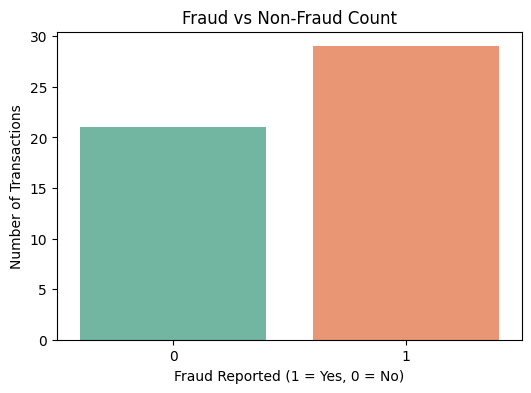

FraudReported
1    58.0
0    42.0
Name: proportion, dtype: float64


In [7]:
plt.figure(figsize=(6,4))
sns.countplot(x='FraudReported', data=df, palette='Set2')
plt.title('Fraud vs Non-Fraud Count')
plt.xlabel('Fraud Reported (1 = Yes, 0 = No)')
plt.ylabel('Number of Transactions')
plt.show()

fraud_percentage = df['FraudReported'].value_counts(normalize=True) * 100
print(fraud_percentage.round(2))

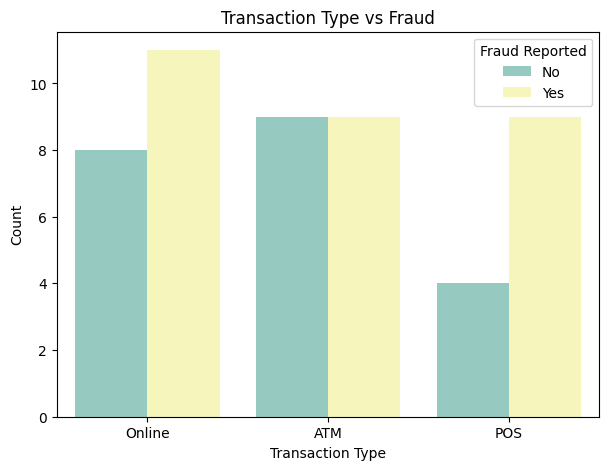

In [8]:
txn_cols = [col for col in df.columns if col.startswith('TransactionType_')]
df_txn = df.copy()

# Map dummy columns back to names for plotting
df_txn['TransactionType'] = df_txn[txn_cols].idxmax(axis=1).str.replace('TransactionType_', '')

plt.figure(figsize=(7,5))
sns.countplot(x='TransactionType', hue='FraudReported', data=df_txn, palette='Set3')
plt.title('Transaction Type vs Fraud')
plt.xlabel('Transaction Type')
plt.ylabel('Count')
plt.legend(title='Fraud Reported', labels=['No', 'Yes'])
plt.show()


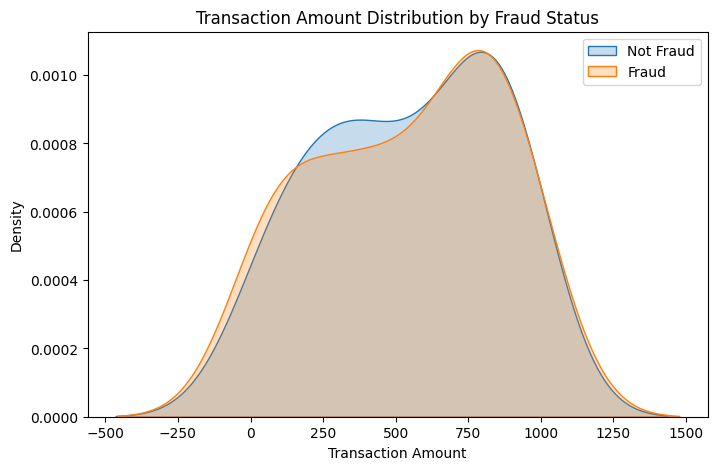

In [9]:
plt.figure(figsize=(8,5))
sns.kdeplot(x='Amount', data=df[df['FraudReported']==0], label='Not Fraud', fill=True)
sns.kdeplot(x='Amount', data=df[df['FraudReported']==1], label='Fraud', fill=True)
plt.title('Transaction Amount Distribution by Fraud Status')
plt.xlabel('Transaction Amount')
plt.ylabel('Density')
plt.legend()
plt.show()


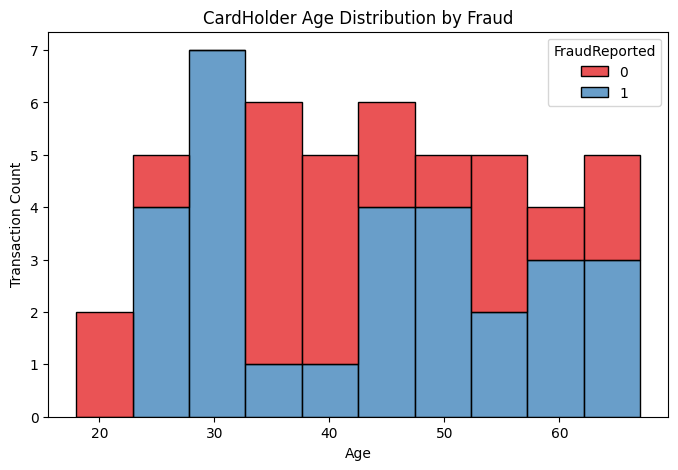

In [10]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='CardHolderAge', hue='FraudReported', multiple='stack', bins=10, palette='Set1')
plt.title('CardHolder Age Distribution by Fraud')
plt.xlabel('Age')
plt.ylabel('Transaction Count')
plt.show()


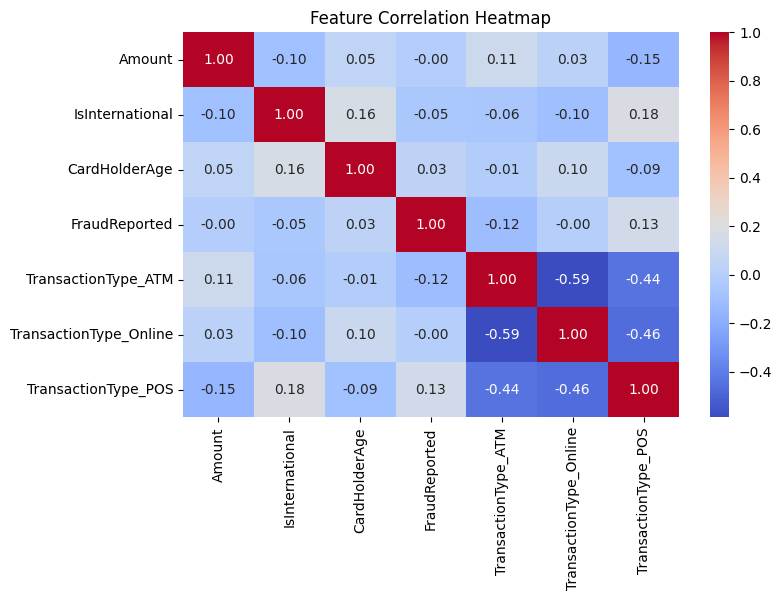

In [11]:
plt.figure(figsize=(8,5))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()


In [12]:
summary = df.groupby('FraudReported').agg({
    'Amount': ['mean', 'max', 'min'],
    'CardHolderAge': ['mean', 'max', 'min'],
    'IsInternational': 'mean'
})
display(summary)


Amount                CardHolderAge         IsInternational
                    mean     max    min          mean max min            mean
FraudReported                                                                
0              544.79000  940.83  33.04     42.095238  66  18        0.571429
1              541.71069  990.60  28.04     43.034483  67  23        0.517241

## Model Building and Evaluation:

In [13]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print("Train shape:", X_train.shape, "Test shape:", X_test.shape)


Train shape: (40, 6) Test shape: (10, 6)


### Random Forest

In [14]:
# Random Forest
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced'
)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
acc_rf = accuracy_score(y_test, y_pred_rf)
print(f"\nRandom Forest Accuracy: {acc_rf:.3f}")
print("Classification Report (RF):\n", classification_report(y_test, y_pred_rf))


Random Forest Accuracy: 0.500
Classification Report (RF):
               precision    recall  f1-score   support

           0       0.40      0.50      0.44         4
           1       0.60      0.50      0.55         6

    accuracy                           0.50        10
   macro avg       0.50      0.50      0.49        10
weighted avg       0.52      0.50      0.51        10



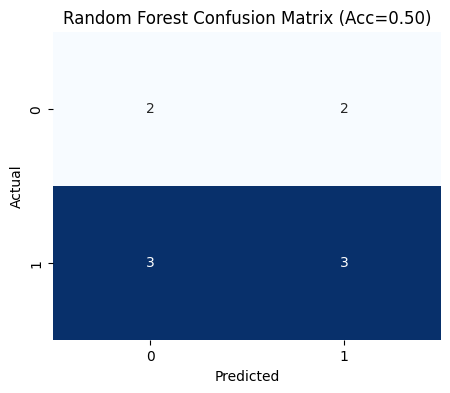

In [15]:
# RF Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(5,4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title(f'Random Forest Confusion Matrix (Acc={acc_rf:.2f})')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### SMOTE

In [23]:
from imblearn.over_sampling import SMOTE
print("imblearn import OK")


imblearn import OK


In [24]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_train, y_train)
print("Before SMOTE:\n", y_train.value_counts())
print("After SMOTE:\n", y_res.value_counts())
rf_model.fit(X_res, y_res)
y_pred_smote = rf_model.predict(X_test)
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_smote))


Before SMOTE:
 FraudReported
1    23
0    17
Name: count, dtype: int64
After SMOTE:
 FraudReported
0    23
1    23
Name: count, dtype: int64
              precision    recall  f1-score   support

           0       0.40      0.50      0.44         4
           1       0.60      0.50      0.55         6

    accuracy                           0.50        10
   macro avg       0.50      0.50      0.49        10
weighted avg       0.52      0.50      0.51        10



### Hyperparameter Tuning

In [25]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold


In [26]:
# Define parameter grid
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

# Stratified 3-fold CV (better for imbalanced/small data)
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# Initialize base model
rf = RandomForestClassifier(random_state=42, class_weight='balanced')

# Create GridSearchCV object (optimize for F1-score)
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring='f1',
    cv=cv,
    n_jobs=-1,
    verbose=1
)


In [27]:
# Fit the grid search on the *balanced* (SMOTE) training data
grid_search.fit(X_res, y_res)

# Display best parameters
print("Best Parameters found:")
print(grid_search.best_params_)
print(f"Best cross-validated F1 score: {grid_search.best_score_:.3f}")


Fitting 3 folds for each of 36 candidates, totalling 108 fits
Best Parameters found:
{'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}
Best cross-validated F1 score: 0.621



 Classification Report (Tuned Random Forest):
              precision    recall  f1-score   support

           0       0.40      0.50      0.44         4
           1       0.60      0.50      0.55         6

    accuracy                           0.50        10
   macro avg       0.50      0.50      0.49        10
weighted avg       0.52      0.50      0.51        10

Accuracy on Test Set: 0.50


Text(33.22222222222222, 0.5, 'Actual')

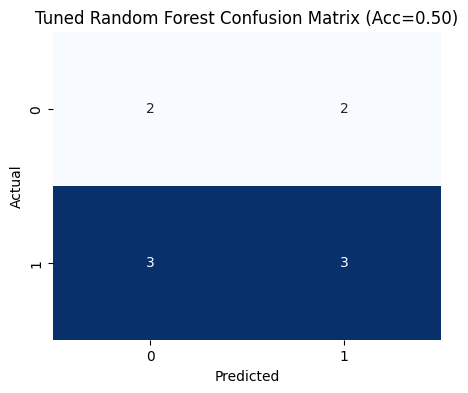

In [29]:
best_rf = grid_search.best_estimator_
y_pred_best = best_rf.predict(X_test)

print("\n Classification Report (Tuned Random Forest):")
print(classification_report(y_test, y_pred_best))

acc_best = accuracy_score(y_test, y_pred_best)
print(f"Accuracy on Test Set: {acc_best:.2f}")

# Confusion matrix
cm_best = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(5,4))
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title(f'Tuned Random Forest Confusion Matrix (Acc={acc_best:.2f})')
plt.xlabel('Predicted')
plt.ylabel('Actual')

In [32]:
# Compare all RF versions

results_comparison = pd.DataFrame({
    'Model': [
        'Random Forest (Base)',
        'Random Forest + SMOTE',
        'Tuned Random Forest'
    ],
    'Accuracy': [
        acc_rf,  # base
        acc_rf,   # after SMOTE
        acc_best     # tuned
    ],
    'F1 (CV/Train)': [
        None,         # base had no CV tuning
        None,         # SMOTE model not tuned
        grid_search.best_score_  # tuned model CV F1
    ]
})

print(" Model Comparison Summary:")
display(results_comparison)


 Model Comparison Summary:


,Model,Accuracy,F1 (CV/Train)
0,Random Forest (Base),0.5,NaN
1,Random Forest + SMOTE,0.5,NaN
2,Tuned Random Forest,0.5,0.621032
